In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.models import load_model
# from tensorflow.keras.layers import Dense, Input
# import tensorflow_addons as tfa


# Carga de datos

In [2]:

# URL base de la API
base_url_ws_col = "https://www.datos.gov.co/resource/57ur-5p28.csv"

# Parámetros
limit = 1000  # número máximo permitido por la API
offset = 0    # desplazamiento inicial
all_data = [] # lista para almacenar los bloques

csv_file_ws_col = "..\\data\\datos_eh_bcmga_2021.csv"


In [3]:
if os.path.exists(csv_file_ws_col):
    ws_col = pd.read_csv(csv_file_ws_col)
    print("Se carga el archivo csv")
else:
    while True:
        # Construir URL con paginación
        url = f"{base_url_ws_col}?$limit={limit}&$offset={offset}"
        print(f"Descargando: {url}")

        # Hacer la solicitud
        response = requests.get(url)
        
        # Si falla la solicitud, salir
        if response.status_code != 200:
            print(f"Error en la descarga: {response.status_code}")
            break

        # Leer el bloque como DataFrame
        df_chunk = pd.read_csv(StringIO(response.text))
        
        # Si el bloque está vacío, terminamos
        if df_chunk.empty:
            break
        
        # Agregar a la lista
        all_data.append(df_chunk)
        
        # Aumentar el offset para el siguiente bloque
        offset += limit
    # Unir todos los bloques en un solo DataFrame
    ws_col = pd.concat(all_data, ignore_index=True)

    print(f"Total de registros descargados: {len(ws_col)}")

    ws_col.to_csv(csv_file_ws_col, index=False)


Se carga el archivo csv


# Preprocesamiento

In [4]:
# Copia del df original
df_col = ws_col.copy()

In [5]:
df_col.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index
0,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T00:00:00.000,22.1,98.0,0.0,SE,676.0,0.0,0.0,-999.0
1,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T01:00:00.000,20.3,96.0,0.4,SE,676.2,5.2,0.0,-999.0
2,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T02:00:00.000,20.1,99.0,0.4,WSW,675.8,25.6,0.0,-999.0
3,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T03:00:00.000,19.6,99.0,0.4,SSE,675.6,6.0,0.0,-999.0
4,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01T00:00:00.000,1899-12-31T04:00:00.000,19.8,99.0,0.0,SSE,675.9,0.2,0.0,-999.0


En la columna `dir` se cambia los valores cardinales a grados

In [6]:
cardinal_to_deg = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5
}


In [7]:

# Normalizar a string para detectar cardinales
df_col['dir'] = df_col['dir'].astype(str).str.strip().str.upper()

# Convertir cardinales a grados
df_col['dir_deg'] = df_col['dir'].map(cardinal_to_deg)

# Si no es cardinal, intentar convertir a número
df_col['dir_deg'] = df_col['dir_deg'].fillna(pd.to_numeric(df_col['dir'], errors='coerce'))

# Reemplazar valores inválidos
df_col['dir_deg'] = df_col['dir_deg'].replace([-999, -999.0], np.nan)

# Si hay valores > 360, llevarlos al rango [0,360)
df_col['dir_deg'] = df_col['dir_deg'] % 360

Se arregla la columna `bar` que indica la presión registrada

In [8]:
# Reemplazar valores inválidos
df_col['bar'] = df_col['bar'].replace([-999, -999.0], np.nan)

Se arregla la columna `speed` que indica la velocidad del viento registrada

In [9]:
(df_col["speed"].value_counts() / df_col.shape[0]).apply(lambda a: f"{100 * a:.2f} %")

speed
 0.000      32.23 %
-999.000    17.57 %
 0.400      11.99 %
 0.900       6.94 %
 1.300       4.53 %
             ...   
 1.148       0.00 %
 1.472       0.00 %
 1.252       0.00 %
 0.633       0.00 %
 1.525       0.00 %
Name: count, Length: 874, dtype: object

In [10]:
# # Reemplazar valores inválidos
# df_col['speed'] = df_col['speed'].replace([-999, -999.0], np.nan)

Se toma las columnas `date` y `time` para ser combinadas y obtener la columnas `datetime`

In [11]:
# Supongamos que df_col tiene las columnas 'date' y 'time'
df_col['date'] = pd.to_datetime(df_col['date'])
df_col['time'] = pd.to_datetime(df_col['time']).dt.time  # extraer solo la hora

# Combinar
df_col['datetime'] = df_col.apply(lambda row: pd.Timestamp.combine(row['date'], row['time']), axis=1)


Se elimnan los valores `nan` del dataframe

In [12]:
df_col.shape

(138566, 16)

In [13]:
df_col = df_col.loc[
    ~ df_col["dir_deg"].isna() &
    ~ df_col["bar"].isna()
].copy()

df_col.shape

(77664, 16)

In [14]:
f"Se conserva un total de {100 * df_col.shape[0] / ws_col.shape[0]:.2f}% de los datos originales"

'Se conserva un total de 56.05% de los datos originales'

In [15]:
df_col.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index,dir_deg,datetime
0,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,00:00:00,22.1,98.0,0.0,SE,676.0,0.0,0.0,-999.0,135.0,2021-06-01 00:00:00
1,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,01:00:00,20.3,96.0,0.4,SE,676.2,5.2,0.0,-999.0,135.0,2021-06-01 01:00:00
2,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,02:00:00,20.1,99.0,0.4,WSW,675.8,25.6,0.0,-999.0,247.5,2021-06-01 02:00:00
3,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,03:00:00,19.6,99.0,0.4,SSE,675.6,6.0,0.0,-999.0,157.5,2021-06-01 03:00:00
4,ACAPULCO,CLIMATOLOGICA,1102787,1265648,2021-06-01,04:00:00,19.8,99.0,0.0,SSE,675.9,0.2,0.0,-999.0,157.5,2021-06-01 04:00:00


In [16]:
fechas , conteo = np.unique(df_col["datetime"], return_counts=True)

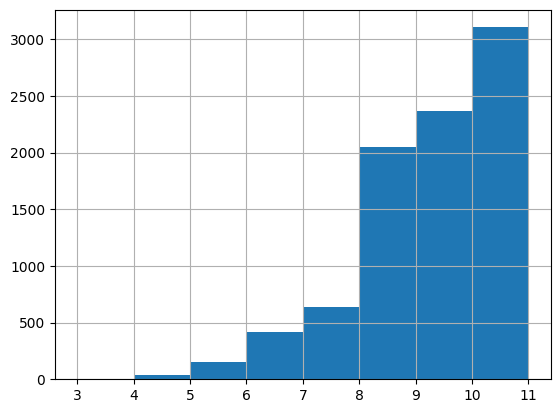

In [17]:
plt.hist(conteo, bins=len(np.unique(conteo))- 1)
plt.grid()
plt.show()

Se necesita que las estaciones tengas la misma cantidad y los mismo registros de fecha

In [18]:
top_fechas = (df_col["datetime"].value_counts()[df_col["datetime"].value_counts() >= 9].index)

In [19]:
df_cln = df_col[df_col["datetime"].isin(top_fechas)].copy()

In [20]:
df_col.shape , df_cln.shape

((77664, 16), (53425, 16))

In [21]:
df_cln = df_cln.sort_values("datetime").reset_index(drop=True)

In [22]:
df_cln["datetime"].diff().value_counts().head()

datetime
0 days 00:00:00    47955
0 days 01:00:00     5306
0 days 02:00:00       41
0 days 17:00:00       17
0 days 16:00:00       16
Name: count, dtype: int64

In [23]:
df_cln["datetime"].diff().sample(5)

37425   0 days
7853    0 days
13302   0 days
42563   0 days
733     0 days
Name: datetime, dtype: timedelta64[ns]

In [24]:
idx = 22801
count = 1
grupos_fechas = dict()
delta_tiempo = df_cln.loc[[idx, idx + 1], "datetime"].diff()[idx + 1]
delta_tiempo

Timedelta('0 days 03:00:00')

In [25]:
df_cln.loc[[22801, 22802, 22803], "datetime"].diff()
df_cln.loc[[22801, 22802, 22803], "datetime"]

22801   2021-06-14 06:00:00
22802   2021-06-14 09:00:00
22803   2021-06-14 09:00:00
Name: datetime, dtype: datetime64[ns]

In [26]:
# for idx in [22800, 22801, 22802, 22803]:
grupos_fechas = dict()
count = 1
for idx in range(df_cln.shape[0] - 1):
    if not f"grupo_{count}" in grupos_fechas: grupos_fechas[f"grupo_{count}"] = list()
    delta_tiempo = df_cln.loc[[idx, idx + 1], "datetime"].diff()[idx + 1]
    if delta_tiempo in [dt.timedelta(hours=0), dt.timedelta(hours=1)]:
        grupos_fechas[f"grupo_{count}"].append(idx + 1)
    else:
        count += 1
        grupos_fechas[f"grupo_{count}"] = [idx + 1]
    ...

In [27]:
len(grupos_fechas)

164

In [28]:
grupos_fechas_largo = {k: len(l) for k, l in grupos_fechas.items()}
grupo_mas_largo = max(grupos_fechas_largo.values())
for k, l in grupos_fechas_largo.items():
    if l == grupo_mas_largo:
        print(k)

grupo_67


In [29]:
print(f"""
min: {df_cln.loc[grupos_fechas["grupo_67"], "datetime"].unique().max()}
max: {df_cln.loc[grupos_fechas["grupo_67"], "datetime"].unique().min()}
unq: {len(df_cln.loc[grupos_fechas["grupo_67"], "datetime"].unique())}
      """)


min: 2021-07-31 23:00:00
max: 2021-06-30 12:00:00
unq: 756
      


In [30]:
df_cln.loc[grupos_fechas["grupo_67"], "datetime"].value_counts()

datetime
2021-07-13 06:00:00    11
2021-07-17 04:00:00    11
2021-07-17 06:00:00    11
2021-07-27 08:00:00    11
2021-07-17 08:00:00    11
                       ..
2021-07-12 08:00:00     9
2021-07-12 09:00:00     9
2021-07-14 01:00:00     9
2021-07-14 04:00:00     9
2021-06-30 12:00:00     9
Name: count, Length: 756, dtype: int64

## g67

In [31]:
g67 = df_cln.loc[grupos_fechas["grupo_67"]].copy()

In [32]:
g67.shape

(8086, 16)

In [33]:
g67["estaci_n"].value_counts()

estaci_n
BETANIA         756
EL ROBLE        756
EL RASGÓN       756
EL DIAMANTE     756
LA NARANJERA    756
LAGO ALTO       756
LA AGUADA       756
LA JUDIA        735
TURBAY          735
ACAPULCO        695
PORTUGAL        629
Name: count, dtype: int64

In [34]:
estaciones_ok_g67 = list()
for estacion in g67["estaci_n"].unique():
    info = g67.loc[g67["estaci_n"] == estacion, "datetime"].diff().unique()
    if len(info) == 2 and estacion != "ACAPULCO":
        print(estacion)
        estaciones_ok_g67.append(estacion)
        # print(f"{info}")

BETANIA
EL ROBLE
EL RASGÓN
EL DIAMANTE
LA NARANJERA
LAGO ALTO
LA AGUADA


In [35]:
for estacion in estaciones_ok_g67:
    fecha_min = g67.loc[g67["estaci_n"] == estacion, "datetime"].min()
    fecha_max = g67.loc[g67["estaci_n"] == estacion, "datetime"].max()
    print(f"""
estacion:   {estacion}
fecha min:  {fecha_min}
fecha max:  {fecha_max}
          """)


estacion:   BETANIA
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   EL ROBLE
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   EL RASGÓN
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   EL DIAMANTE
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   LA NARANJERA
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   LAGO ALTO
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          

estacion:   LA AGUADA
fecha min:  2021-06-30 12:00:00
fecha max:  2021-07-31 23:00:00
          


In [36]:
g67 = g67[g67["estaci_n"].isin(estaciones_ok_g67)].copy()

In [37]:
g67["datetime"].value_counts().sort_values()

datetime
2021-06-30 12:00:00    7
2021-07-01 09:00:00    7
2021-06-30 14:00:00    7
2021-06-30 15:00:00    7
2021-06-30 16:00:00    7
                      ..
2021-07-31 17:00:00    7
2021-07-31 18:00:00    7
2021-07-31 19:00:00    7
2021-07-31 10:00:00    7
2021-07-31 23:00:00    7
Name: count, Length: 756, dtype: int64

In [38]:
g67.head()

,estaci_n,tipo,coordenada_x,coordenada_y,date,time,out,hum,speed,dir,bar,rain,rad,index,dir_deg,datetime
26614,BETANIA,CLIMATOLOGICA,1100932,1327382,2021-06-30,12:00:00,25.3,87.0,0.9,WNW,675.3,0.0,485.0,-999.0,292.5,2021-06-30 12:00:00
26615,EL ROBLE,CLIMATOLOGICA,1123600,1294826,2021-06-30,12:00:00,18.3,80.0,0.9,NW,583.3,0.0,493.0,-999.0,315.0,2021-06-30 12:00:00
26616,EL RASGÓN,CLIMATOLOGICA,1119338,1270464,2021-06-30,12:00:00,16.9,89.0,1.8,SW,592.1,0.0,212.0,-999.0,225.0,2021-06-30 12:00:00
26617,EL DIAMANTE,CLIMATOLOGICA,1097379,1298389,2021-06-30,12:00:00,24.5,90.0,3.1,NNW,672.8,0.0,691.0,8.5,337.5,2021-06-30 12:00:00
26618,LA NARANJERA,CLIMATOLOGICA,1097833,1318507,2021-06-30,12:00:00,28.6,78.0,1.3,SW,792.9,0.0,593.0,-999.0,225.0,2021-06-30 12:00:00


In [39]:
g67.isna().sum()

estaci_n        0
tipo            0
coordenada_x    0
coordenada_y    0
date            0
time            0
out             0
hum             0
speed           0
dir             0
bar             0
rain            0
rad             0
index           0
dir_deg         0
datetime        0
dtype: int64

In [40]:
g67.values.T

array([['BETANIA', 'EL ROBLE', 'EL RASGÓN', ..., 'LAGO ALTO',
        'EL RASGÓN', 'EL DIAMANTE'],
       ['CLIMATOLOGICA', 'CLIMATOLOGICA', 'CLIMATOLOGICA', ...,
        'CLIMATOLOGICA', 'CLIMATOLOGICA', 'CLIMATOLOGICA'],
       [1100932, 1123600, 1119338, ..., 1122963, 1119338, 1097379],
       ...,
       [-999.0, -999.0, -999.0, ..., 0.0, -999.0, 0.0],
       [292.5, 315.0, 225.0, ..., 315.0, 0.0, 90.0],
       [Timestamp('2021-06-30 12:00:00'),
        Timestamp('2021-06-30 12:00:00'),
        Timestamp('2021-06-30 12:00:00'), ...,
        Timestamp('2021-07-31 23:00:00'),
        Timestamp('2021-07-31 23:00:00'),
        Timestamp('2021-07-31 23:00:00')]], dtype=object)

In [41]:
data = g67.sort_values(["estaci_n", "datetime"]).reset_index(drop=True).copy()

## data

In [42]:
data.apply(lambda df: df["estaci_n"] + " " + str(df["coordenada_x"]) + " " + str(df["coordenada_y"]), axis=1).value_counts()

BETANIA 1100932 1327382         756
EL DIAMANTE 1097379 1298389     756
EL RASGÓN 1119338 1270464       756
EL ROBLE 1123600 1294826        756
LA AGUADA 1108114 1318657       756
LA NARANJERA 1097833 1318507    756
LAGO ALTO 1122963 1314363       756
Name: count, dtype: int64

Se convierte a tiempo continuo: desde el formato decha a segundos

In [43]:
time_init = data["datetime"][0]
seconds = np.zeros((data.shape[0], 1))
for index in range(data.shape[0]):
    seconds[index, 0] = ((data.loc[index, "datetime"] - time_init).total_seconds())
T = seconds


In [44]:
X = np.array([val for val in data["coordenada_x"]])
Y = np.array([val for val in data["coordenada_y"]])

Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [45]:
U = np.array([val for val in data["speed"] * np.cos(data["dir_deg"]*(np.pi/180))])
V = np.array([val for val in data["speed"] * np.sin(data["dir_deg"]*(np.pi/180))])

Presión de mbar a Pa

In [46]:
P = np.array([val for val in data["bar"]])

Se estructura la información en una matriz: 7 estaciones `(filas)` $\times$ medidas cada 60 min `(columnas)`

In [47]:
T = np.reshape(T, (7, T.shape[0] // 7))
X = np.reshape(X, (T.shape[0],T.shape[1]))
Y = np.reshape(Y, (T.shape[0],T.shape[1]))
U = np.reshape(U, (T.shape[0],T.shape[1]))
V = np.reshape(V, (T.shape[0],T.shape[1]))
P = np.reshape(P, (T.shape[0],T.shape[1]))


Se ordena la matriz con el incremeto de los valores en la coordenada X

In [48]:
for snap in range(0, T.shape[1]):
    index_sort = np.argsort(X[:, snap])
    T[:, snap] = T[index_sort, snap]
    X[:, snap] = X[index_sort, snap]
    Y[:, snap] = Y[index_sort, snap]
    U[:, snap] = U[index_sort, snap]
    V[:, snap] = V[index_sort, snap]
    P[:, snap] = P[index_sort, snap]

Centrando los valores de localización y tiempo

In [49]:
x_min = np.min(X).astype(np.int64)
x_max = np.max(X).astype(np.int64)
X = X - (x_min + x_max) / 2
y_min = np.min(Y).astype(np.int64)
y_max = np.max(Y).astype(np.int64)
Y = Y - (y_min + y_max) / 2
t_min = np.min(T)
t_max = np.max(T)
T = T - t_min # Refer to t = 0

Valores de referencia para la no-dimensionalización

In [50]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U)) ** 2 + np.nanmax(abs(V)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

L: 62667.37241180613 W 5.202119946914799 P0 668.345842781557 Re 23589232130


No-dimensonalización

In [51]:
X = X / L
Y = Y / L
T = T * W / L
P = (P - P0) / rho / (W ** 2)
U = U / W
V = V / W

In [55]:
import scipy.io as sio

sio.savemat("processed_data_bmanga.mat", {
    "X_WS" : X,
    "Y_WS" : Y,
    "T_WS" : T,
    "P_WS" : P,
    "U_WS" : U,
    "V_WS" : V,
})

# Gráficas

In [52]:
print(f"{X.shape=}")
print(f"{Y.shape=}")
print(f"{T.shape=}")
print(f"{P.shape=}")
print(f"{U.shape=}")
print(f"{V.shape=}")


X.shape=(7, 756)
Y.shape=(7, 756)
T.shape=(7, 756)
P.shape=(7, 756)
U.shape=(7, 756)
V.shape=(7, 756)


In [53]:
def info_estacion(n_estacion:int):
    fig, ax = plt.subplots(2,2,figsize=(9,6))
    ax[0,0].scatter(X[:,0], Y[:,0])
    ax[0,0].scatter(X[n_estacion,:], Y[n_estacion,:])
    ax[0,0].set_title("Posición")
    ax[0,0].grid()
    
    ax[0,1].plot(P[n_estacion,:])
    ax[0,1].set_title("Presión")
    ax[0,1].grid()
    
    ax[1,0].plot(V[n_estacion,:])
    ax[1,0].set_title("velocidad en v")
    ax[1,0].grid()

    ax[1,1].plot(U[n_estacion,:])
    ax[1,1].set_title("velocidad en u")
    ax[1,1].grid()
    
    plt.show()

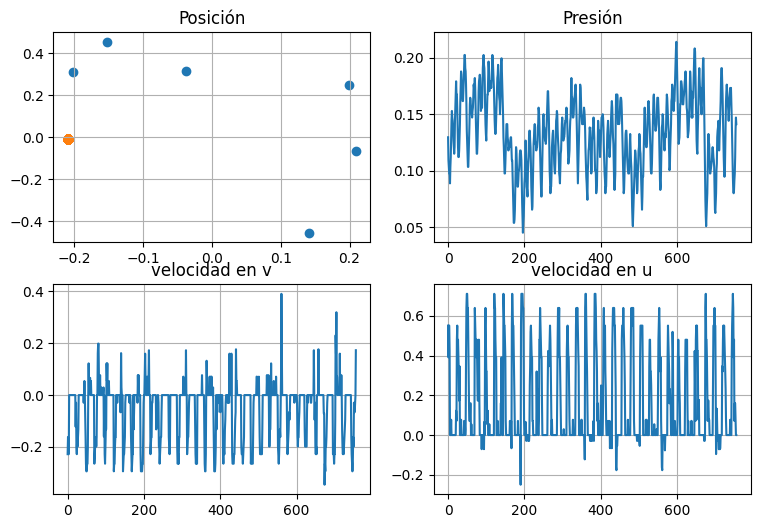

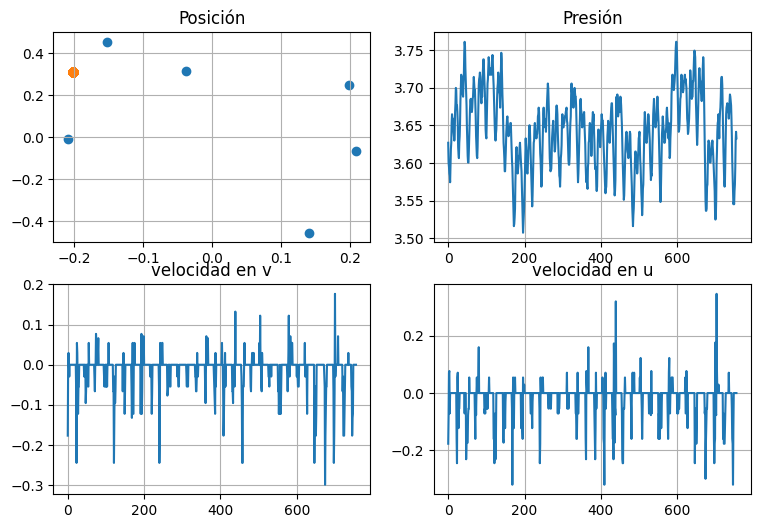

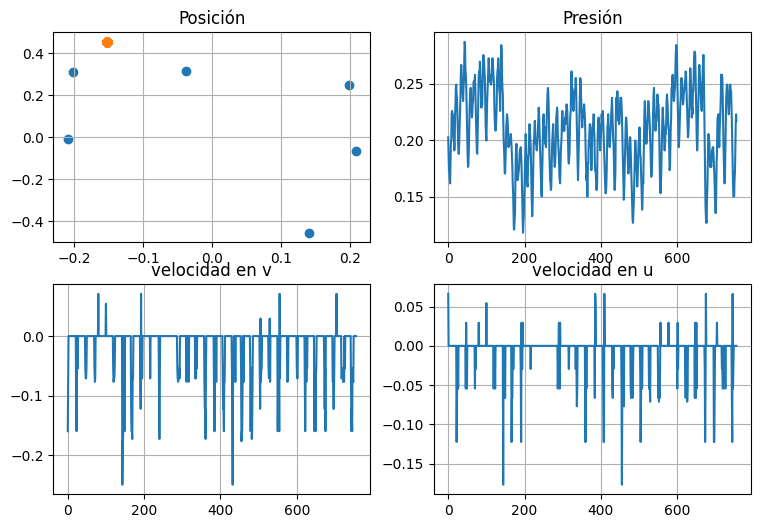

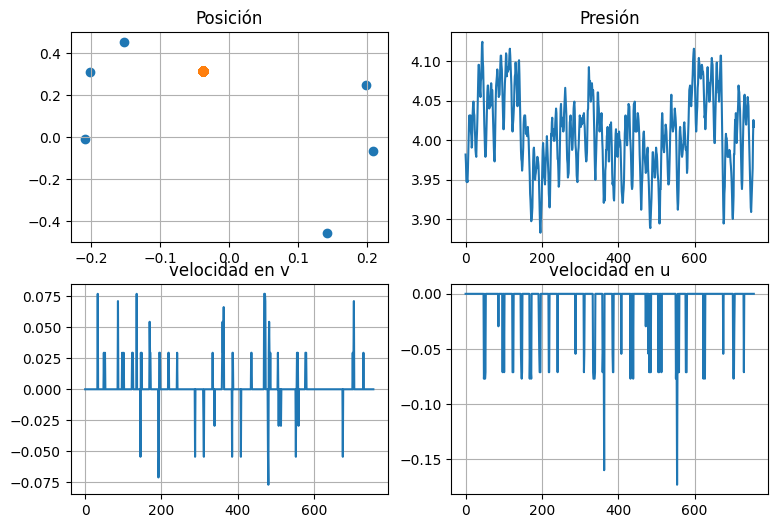

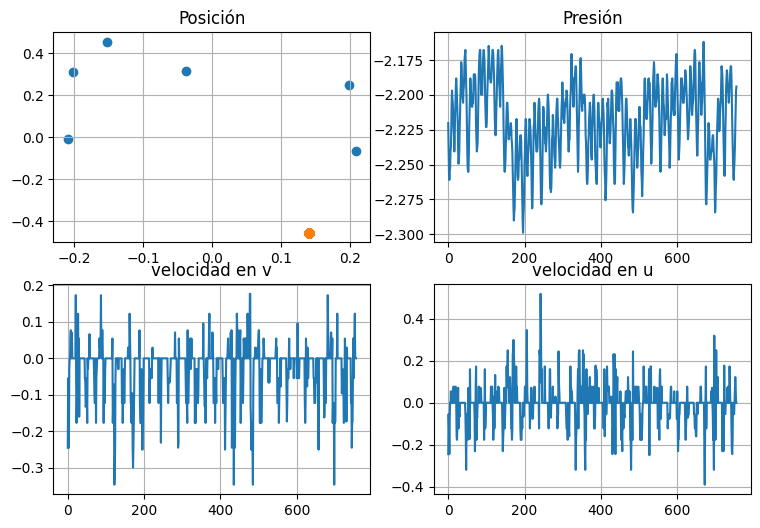

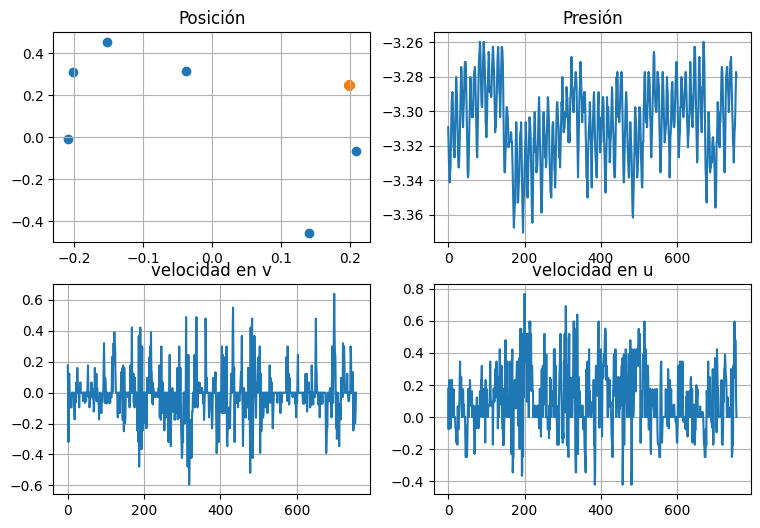

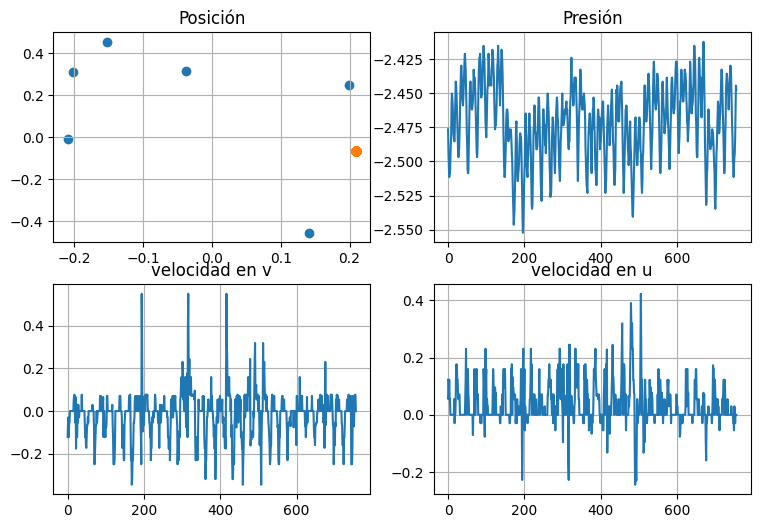

In [54]:
for n in range(0,7):
    info_estacion(n)